# Lab 8-kNN

# Imports
    

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

# Load Dataset

In [ ]:
iris = pd.read_csv("Iris.csv") #Load Dataset
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
iris.drop('Id',inplace=True,axis=1) #Drop Id column

In [ ]:
iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
#X is a pandas dataframe (2D) with 150 rows and 4 cols, take all rows and take all cols except last col
X = iris.iloc[:,:-1].values #Set our training data
print(X.shape)
print(X)

#y is a pandas series (1D) with one coloumn
y = iris.iloc[:,-1].values #Set target labels
print(y.shape)
print(y)

(150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6

# KNN Implementation From Scratch
  



## How the algorithm works

We calculate the distance between a new sample and all points

We determine the label of the sample based on the majority vote

In [ ]:
class KNN:
    """
    K-Nearest Neighbors (KNN) classification algorithm

    Parameters:
    -----------
    n_neighbors : int, optional (default=5)
        Number of neighbors to use in the majority vote.

    Methods:
    --------
    fit(X_train, y_train):
        Stores the values of X_train and y_train.

    predict(X):
        Predicts the class labels for each example in X.

    """
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def euclidean_distance(self, x1, x2):
        """
        Calculate the Euclidean distance between two data points.

        Parameters:
        -----------
        x1 : numpy.ndarray, shape (n_features,)
            A data point in the dataset.

        x2 : numpy.ndarray, shape (n_features,)
            A data point in the dataset.

        Returns:
        --------
        distance : float
            The Euclidean distance between x1 and x2.
        """
        # Calculate the difference between the two points
        difference = x1 - x2
        # Square the differences
        squared_difference = difference ** 2
        # Sum the squared differences
        sum_of_squared_difference = np.sum(squared_difference)
        # Take the square root of the sum to get the Euclidean distance
        distance = np.sqrt(sum_of_squared_difference)
        return distance

    def manhattan_distance(self, x1, x2):
        """
        Calculate the Manhattan distance between two data points.

        Parameters:
        -----------
        x1 : numpy.ndarray, shape (n_features,)
            A data point in the dataset.

        x2 : numpy.ndarray, shape (n_features,)
            A data point in the dataset.

        Returns:
        --------
        distance : float
            The Manhattan distance between x1 and x2.
        """
        # Calculate the absolute difference between the two points
        absolute_difference = np.abs(x1 - x2)
        # Sum the absolute differences to get the Manhattan distance
        distance = np.sum(absolute_difference)
        return distance

    def fit(self, X_train, y_train):
        """
        Stores the values of X_train and y_train.

        Parameters:
        -----------
        X_train : numpy.ndarray, shape (n_samples, n_features)
            The training dataset.

        y_train : numpy.ndarray, shape (n_samples,)
            The target labels.
        """
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def predict(self, X, distance_metric='euclidean'):
        """
        Predicts the class labels for each example in X.

        Parameters:
        -----------
        X : numpy.ndarray, shape (n_samples, n_features)
            The test dataset.

        Returns:
        --------
        predictions : numpy.ndarray, shape (n_samples,)
            The predicted class labels for each example in X.
        """
        # Create empty array to store the predictions
        predictions = []
        # Loop over X examples
        for x in X:
            # Get prediction using the prediction helper function
            prediction = self._predict(x,distance_metric)
            # Append the prediction to the predictions list
            predictions.append(prediction)
        return np.array(predictions)

    def _predict(self, x, distance_metric='euclidean'):
        """
        Predicts the class label for a single example.

        Parameters:
        -----------
        x : numpy.ndarray, shape (n_features,)
            A data point in the test dataset.

        Returns:
        --------
        most_occuring_value : int
            The predicted class label for x.
        """
        # Create empty array to store distances
        distances = []
        # Loop over all training examples and compute the distance between x and all the training examples
        for x_train in self.X_train:
            if distance_metric == 'euclidean':
                distance = self.euclidean_distance(x, x_train)
            elif distance_metric == 'manhattan':
                distance = self.manhattan_distance(x, x_train)
            distances.append(distance)
        distances = np.array(distances)

        # Sort by ascendingly distance and return indices of the given n neighbours
        n_neighbors_idxs = np.argsort(distances)[:self.n_neighbors]

        # Get labels of n-neighbour indexes
        labels = self.y_train[n_neighbors_idxs]
        labels = list(labels)
        # Get the most frequent class in the array
        most_occuring_value = max(set(labels), key=labels.count)
        return most_occuring_value

    def visualize(self, x):
        """
        Visualize the training data, the query point x, and the k nearest neighbors.

        Parameters:
        -----------
        x : numpy.ndarray, shape (n_features,)
            The query point to classify and visualize (must be 2D features).
        """
        if self.X_train.shape[1] != 2:
            raise ValueError("Visualization only supported for 2D data.")

        distances = np.array([self.euclidean_distance(x, x_train) for x_train in self.X_train])
        n_neighbors_idxs = np.argsort(distances)[: self.n_neighbors]

        # Plot training points colored by class
        plt.figure(figsize=(8,6))
        for class_value in np.unique(self.y_train):
            idxs = np.where(self.y_train == class_value)
            plt.scatter(self.X_train[idxs, 0], self.X_train[idxs, 1], label=f'Class {class_value}', alpha=0.6)

        # Plot the k nearest neighbors with a circle around them
        neighbors = self.X_train[n_neighbors_idxs]
        plt.scatter(neighbors[:, 0], neighbors[:, 1], s=150, facecolors='none', edgecolors='k', label='Neighbors')

        # Plot the query point colored by predicted class
        predicted_class = self._predict(x)
        plt.scatter(x[0], x[1], c='red', marker='*', s=200, label=f'Query point (Predicted: {predicted_class})')

        plt.title(f'k-NN Visualization (k={self.n_neighbors})')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.grid(True)
        plt.show()

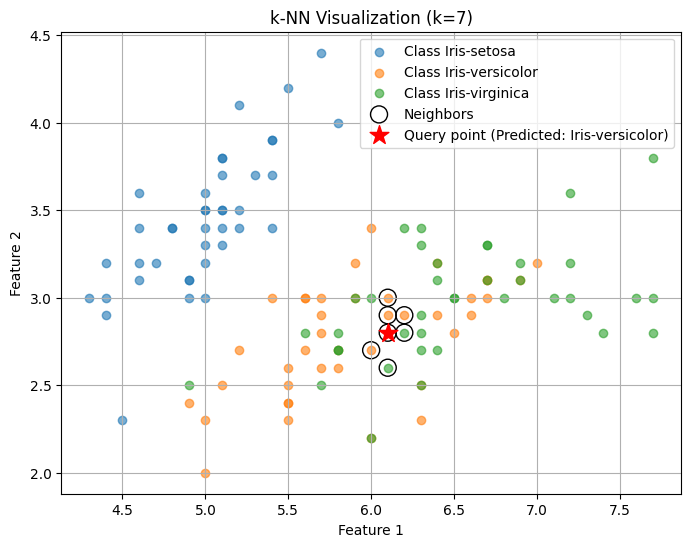

Predicted label for the query point (k=7): Iris-versicolor


In [ ]:
# Create a KNN instance with k=7
model_viz = KNN(n_neighbors=7)

# Fit the model with training data (using only the first two features for visualization)
# We'll use the X_train and y_train that were already split
model_viz.fit(X_train[:, :2], y_train)

# Select a data point from the test set to visualize (using only the first two features)
# You can change the index [0] to visualize a different data point
sample_point = X_test[0, :2]

# Visualize the data and the neighbors for the sample point
model_viz.visualize(sample_point)

# Print the predicted label of the query point
predicted_label = model_viz._predict(sample_point)
print(f"Predicted label for the query point (k=7): {predicted_label}")

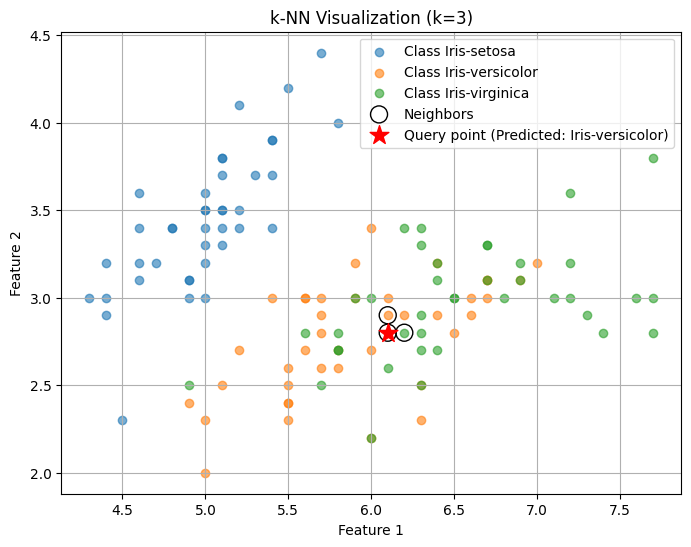

Predicted label for the query point (k=3): Iris-versicolor


In [ ]:
# Create a KNN instance with k=3
model_viz_k3 = KNN(n_neighbors=3)

# Fit the model with training data (using only the first two features for visualization)
model_viz_k3.fit(X_train[:, :2], y_train)

# Select a data point from the test set to visualize (using only the first two features)
# You can change the index [0] to visualize a different data point
sample_point_k3 = X_test[0, :2]

# Visualize the data and the neighbors for the sample point
model_viz_k3.visualize(sample_point_k3)

# Print the predicted label of the query point
predicted_label_k3 = model_viz_k3._predict(sample_point_k3)
print(f"Predicted label for the query point (k=3): {predicted_label_k3}")

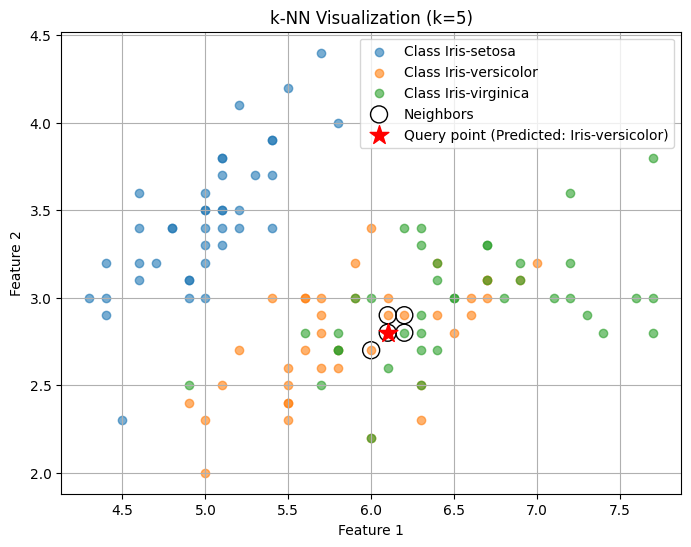

Predicted label for the query point (k=5): Iris-versicolor


In [ ]:
# Create a KNN instance with k=5
model_viz_k5 = KNN(n_neighbors=5)

# Fit the model with training data (using only the first two features for visualization)
model_viz_k5.fit(X_train[:, :2], y_train)

# Select a data point from the test set to visualize (using only the first two features)
# You can change the index [0] to visualize a different data point
sample_point_k5 = X_test[0, :2]

# Visualize the data and the neighbors for the sample point
model_viz_k5.visualize(sample_point_k5)

# Print the predicted label of the query point
predicted_label_k5 = model_viz_k5._predict(sample_point_k5)
print(f"Predicted label for the query point (k=5): {predicted_label_k5}")

## Visualizing the Decision Boundary

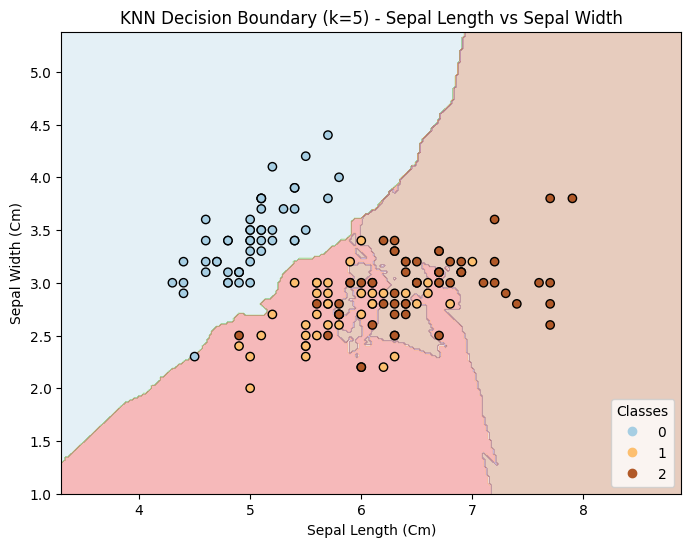

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# We'll use the first two features for visualization (Sepal Length and Sepal Width)
X_viz_sepal = X[:, :2]
y_viz = y

# Encode the target labels to numerical values
label_encoder = LabelEncoder()
y_viz_encoded = label_encoder.fit_transform(y_viz)

# Create a KNN classifier instance (you can change n_neighbors)
knn_viz_sepal = KNeighborsClassifier(n_neighbors=5)

# Train the model on the selected features
knn_viz_sepal.fit(X_viz_sepal, y_viz_encoded)

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_viz_sepal[:, 0].min() - 1, X_viz_sepal[:, 0].max() + 1
y_min, y_max = X_viz_sepal[:, 1].min() - 1, X_viz_sepal[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z_sepal = knn_viz_sepal.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sepal = Z_sepal.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_sepal, alpha=0.3, cmap=plt.cm.Paired)

# Plot the training points
scatter_sepal = plt.scatter(X_viz_sepal[:, 0], X_viz_sepal[:, 1], c=y_viz_encoded, edgecolors='k', cmap=plt.cm.Paired)

# Add labels and title
plt.xlabel('Sepal Length (Cm)')
plt.ylabel('Sepal Width (Cm)')
plt.title('KNN Decision Boundary (k=5) - Sepal Length vs Sepal Width')
plt.legend(*scatter_sepal.legend_elements(), title="Classes", loc="lower right")
plt.show()

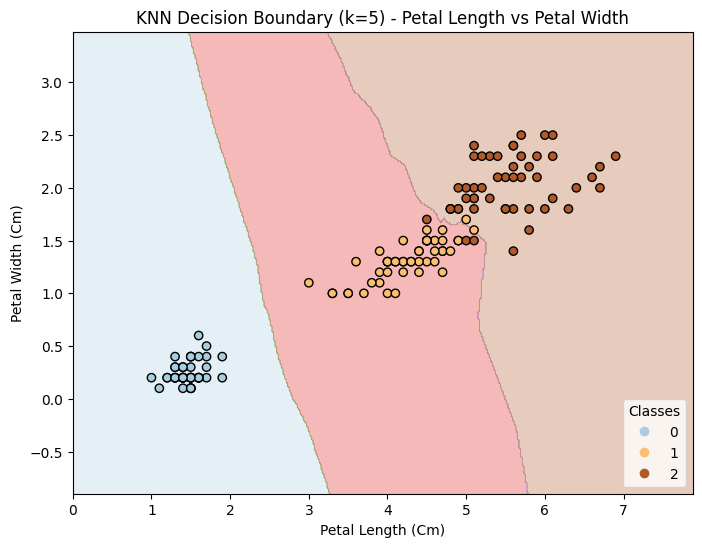

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# We'll use the last two features for visualization (Petal Length and Petal Width)
X_viz_petal = X[:, 2:4]
y_viz = y

# Encode the target labels to numerical values
label_encoder = LabelEncoder()
y_viz_encoded = label_encoder.fit_transform(y_viz)

# Create a KNN classifier instance (you can change n_neighbors)
knn_viz_petal = KNeighborsClassifier(n_neighbors=5)

# Train the model on the selected features
knn_viz_petal.fit(X_viz_petal, y_viz_encoded)

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_viz_petal[:, 0].min() - 1, X_viz_petal[:, 0].max() + 1
y_min, y_max = X_viz_petal[:, 1].min() - 1, X_viz_petal[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z_petal = knn_viz_petal.predict(np.c_[xx.ravel(), yy.ravel()])
Z_petal = Z_petal.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_petal, alpha=0.3, cmap=plt.cm.Paired)

# Plot the training points
scatter_petal = plt.scatter(X_viz_petal[:, 0], X_viz_petal[:, 1], c=y_viz_encoded, edgecolors='k', cmap=plt.cm.Paired)

# Add labels and title
plt.xlabel('Petal Length (Cm)')
plt.ylabel('Petal Width (Cm)')
plt.title('KNN Decision Boundary (k=5) - Petal Length vs Petal Width')
plt.legend(*scatter_petal.legend_elements(), title="Classes", loc="lower right")
plt.show()

## KNN using Scikit-learn

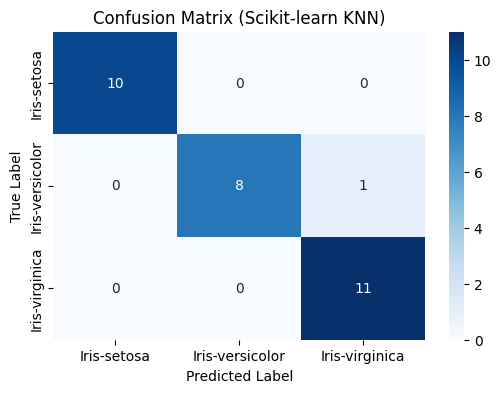

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix for Scikit-learn KNN
cm_sklearn = confusion_matrix(y_test, predictions_sklearn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Scikit-learn KNN)')
plt.show()

In [ ]:
# Evaluate with Euclidean distance
model_euclidean = KNN(n_neighbors=7)
model_euclidean.fit(X_train, y_train)
predictions_euclidean = model_euclidean.predict(X_test, distance_metric='euclidean')
accuracy_euclidean = compute_accuracy(y_test, predictions_euclidean)
print(f"Accuracy with Euclidean distance (k=7): {accuracy_euclidean:}")

Accuracy with Euclidean distance (k=7): 0.9666666666666667


In [ ]:
# Evaluate with Manhattan distance
model_manhattan = KNN(n_neighbors=7)
model_manhattan.fit(X_train, y_train)
predictions_manhattan = model_manhattan.predict(X_test, distance_metric='manhattan')
accuracy_manhattan = compute_accuracy(y_test, predictions_manhattan)
print(f"Accuracy with Manhattan distance (k=7): {accuracy_manhattan:}")

Accuracy with Manhattan distance (k=7): 1.0


### Analysis of Results

Based on the accuracy scores obtained:

- Accuracy with Euclidean distance (k=7): 0.97
- Accuracy with Manhattan distance (k=7): 1.0

Manhattan distance is more accurate based on our analysis.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42) #split the  data into training and validating

In [ ]:
model_k3 = KNN(3)
model_k3.fit(X_train, y_train)
model_k5 = KNN(5)
model_k5.fit(X_train, y_train)
model_k7 = KNN(7)
model_k7.fit(X_train, y_train)

In [ ]:
# Make predictions with Manhattan distance for k=3, k=5 and k=7
predictions_manhattan_k3 = model_k3.predict(X_test, distance_metric='manhattan')
predictions_manhattan_k5 = model_k5.predict(X_test, distance_metric='manhattan')
predictions_manhattan_k7 = model_k7.predict(X_test, distance_metric='manhattan')

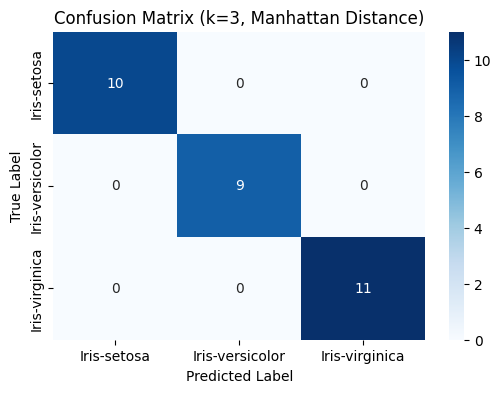

In [ ]:
# Confusion Matrix for k=3 (Manhattan distance)
cm_k3_manhattan = confusion_matrix(y_test, predictions_manhattan_k3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_k3_manhattan, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (k=3, Manhattan Distance)')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

### Evaluate Using Confusion Matrix and Classification Report

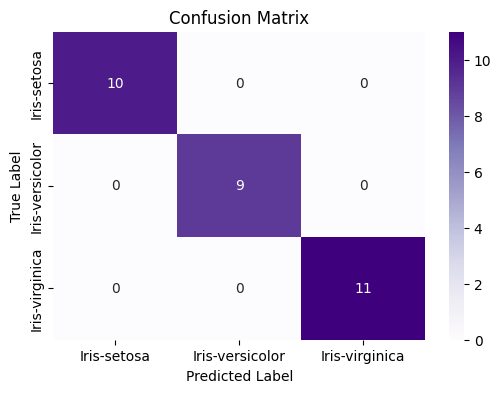


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions_manhattan)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
cr = classification_report(y_test, predictions_manhattan)
print("\nClassification Report:")
print(cr)

In [ ]:
def compute_accuracy(y_true, y_pred):
    """
    Computes the accuracy of a classification model.

    Parameters:
    y_true (numpy array): A numpy array of true labels for each data point.
    y_pred (numpy array): A numpy array of predicted labels for each data point.

    Returns:
    float: The accuracy of the model, expressed as a percentage.
    """
    y_true = y_true.flatten()
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples)

In [ ]:
predictions = model.predict(X_test)
accuracy = compute_accuracy(y_test, predictions)
print(f"Our model got accuracy score of : {accuracy}")

Our model got accuracy score of : 0.9666666666666667
